In [ ]:
!pip install pandas numpy matplotlib seaborn pyreadstat openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 2.3 MB/s eta 0:00:00


In [2]:
from google.colab import files

uploaded = files.upload()

Saving FULL DATA.xlsx to FULL DATA.xlsx


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("FULL DATA.xlsx")

print("Data imported successfully")
print("Rows and columns:", df.shape)

df.head()

Data imported successfully
Rows and columns: (99124, 35)


,caseid,midx,v005,survey_weight,treatment,OBW,OSSB,OCA,OSCA,OS,...,AV,Wealthindex,OtherF,Watersource,ToiletF,HS,Bord,Siblings,BMI,MotherageB
0,1280700967 03,1,8482,0.008482,0,0,0,0,0,0,...,1,2,0,12,12,6,2,1,1842,19
1,1280203798 02,1,55156,0.055156,0,0,0,1,0,0,...,0,3,1,12,12,7,3,2,2310,21
2,0101603318 04,1,202095,0.202095,1,0,0,1,0,0,...,1,5,0,41,14,10,2,4,2284,24
3,1020304378 06,1,2031207,2.031207,0,0,0,1,0,0,...,0,4,1,21,12,9,2,2,2903,19
4,3690601901 04,1,732386,0.732386,1,0,0,0,0,0,...,1,5,0,92,11,7,3,2,2052,24


In [4]:
df.columns

Index(['caseid', 'midx', 'v005', 'survey_weight', 'treatment', 'OBW', 'OSSB',
       'OCA', 'OSCA', 'OS', 'OSS', 'OW', 'OSW', 'OUW', 'OAU', 'OMF',
       'childage', 'Mage', 'Residence', 'Gender', 'Religion', 'Region', 'Zone',
       'Medu', 'Manemia', 'AV', 'Wealthindex', 'OtherF', 'Watersource',
       'ToiletF', 'HS', 'Bord', 'Siblings', 'BMI', 'MotherageB'],
      dtype='object')

In [5]:
missing = df.isnull().sum()
missing[missing > 0]

,0


In [10]:
def weighted_percentage(data, outcome, weight_col="survey_weight"):
    valid = data[[outcome, weight_col]].dropna()
    return (valid[outcome] * valid[weight_col]).sum() / valid[weight_col].sum() * 100

In [11]:
outcome_vars = ["OBW", "OSSB", "OCA", "OSCA", "OS", "OSS", "OW", "OSW", "OUW", "OAU", "OMF"]

overall_results = []

for outcome in outcome_vars:
    value = weighted_percentage(df, outcome)
    overall_results.append({
        "Outcome": outcome,
        "Overall Weighted Percentage": round(value, 2)
    })

overall_results = pd.DataFrame(overall_results)

overall_results

,Outcome,Overall Weighted Percentage
0,OBW,16.84
1,OSSB,10.68
2,OCA,69.19
3,OSCA,2.20
4,OS,81.92
5,OSS,81.76
6,OW,87.05
7,OSW,86.87
8,OUW,74.05
9,OAU,95.95


In [12]:
comparison_table = []

for outcome in outcome_vars:
    for treatment_value, group in df.groupby("treatment"):
        percentage = weighted_percentage(group, outcome)
        comparison_table.append({
            "Outcome": outcome,
            "Treatment": treatment_value,
            "Weighted Percentage": round(percentage, 2)
        })

comparison_table = pd.DataFrame(comparison_table)

comparison_table

,Outcome,Treatment,Weighted Percentage
0,OBW,0,17.85
1,OBW,1,15.95
2,OSSB,0,11.22
3,OSSB,1,10.20
4,OCA,0,70.70
5,OCA,1,67.85
6,OSCA,0,2.35
7,OSCA,1,2.06
8,OS,0,83.08
9,OS,1,80.89


In [13]:
comparison_pivot = comparison_table.pivot(
    index="Outcome",
    columns="Treatment",
    values="Weighted Percentage"
).reset_index()

comparison_pivot.columns.name = None

comparison_pivot

,Outcome,0,1
0,OAU,96.55,95.42
1,OBW,17.85,15.95
2,OCA,70.70,67.85
3,OMF,88.65,85.63
4,OS,83.08,80.89
5,OSCA,2.35,2.06
6,OSS,82.92,80.74
7,OSSB,11.22,10.20
8,OSW,88.53,85.39
9,OUW,75.17,73.05


In [15]:
comparison_pivot["Difference_1_minus_0"] = comparison_pivot[1] - comparison_pivot[0]

comparison_pivot

,Outcome,0,1,Difference_1_minus_0
0,OAU,96.55,95.42,-1.13
1,OBW,17.85,15.95,-1.90
2,OCA,70.70,67.85,-2.85
3,OMF,88.65,85.63,-3.02
4,OS,83.08,80.89,-2.19
5,OSCA,2.35,2.06,-0.29
6,OSS,82.92,80.74,-2.18
7,OSSB,11.22,10.20,-1.02
8,OSW,88.53,85.39,-3.14
9,OUW,75.17,73.05,-2.12


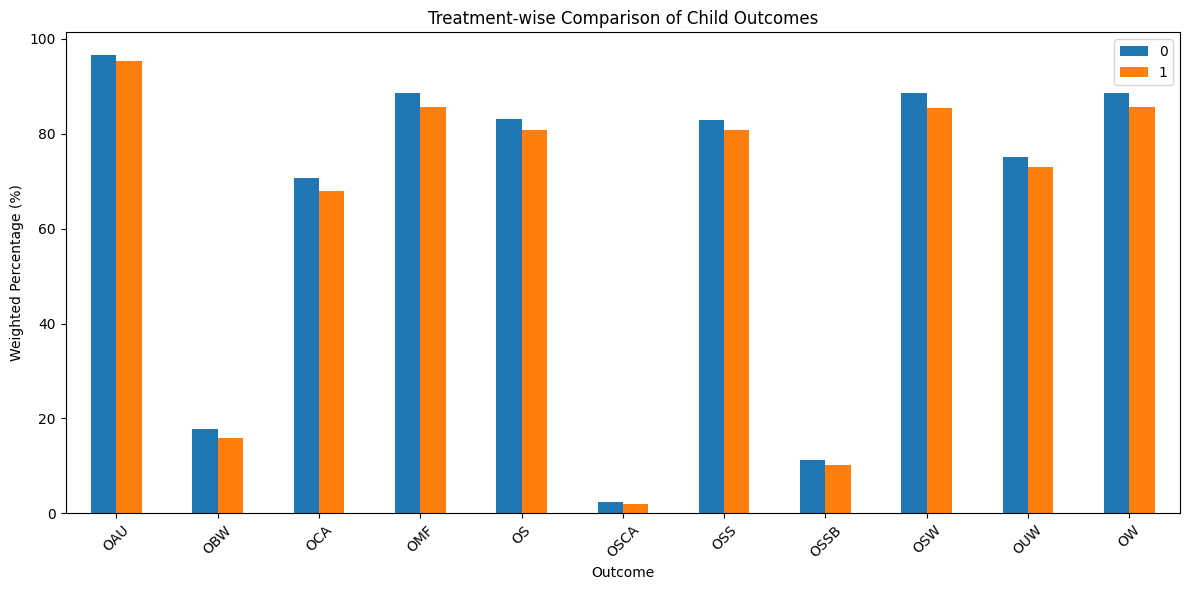

In [16]:
comparison_plot = comparison_pivot.set_index("Outcome")[[0, 1]]

comparison_plot.plot(kind="bar", figsize=(12, 6))

plt.title("Treatment-wise Comparison of Child Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Weighted Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
zone_results = []

for zone, group in df.groupby("Zone"):
    row = {"Zone": zone}

    for outcome in outcome_vars:
        row[outcome + " (%)"] = round(weighted_percentage(group, outcome), 2)

    zone_results.append(row)

zone_results = pd.DataFrame(zone_results)

zone_results

,Zone,OBW (%),OSSB (%),OCA (%),OSCA (%),OS (%),OSS (%),OW (%),OSW (%),OUW (%),OAU (%),OMF (%)
0,Central,18.58,11.61,70.38,2.46,83.36,83.23,88.27,88.14,74.07,96.70,88.27
1,East,16.79,11.91,70.11,1.35,82.96,82.72,89.15,89.01,76.69,96.49,89.15
2,North,17.07,9.11,70.60,2.97,79.29,79.15,81.41,81.19,66.58,93.75,81.39
3,Northeast,12.87,9.99,65.98,0.82,79.79,79.68,85.02,84.89,71.66,95.45,85.02
4,South,14.50,7.66,62.23,2.25,81.72,81.58,85.93,85.62,72.90,95.45,85.93
5,West,18.00,12.63,74.48,2.86,80.94,80.84,88.71,88.57,78.78,96.63,88.72


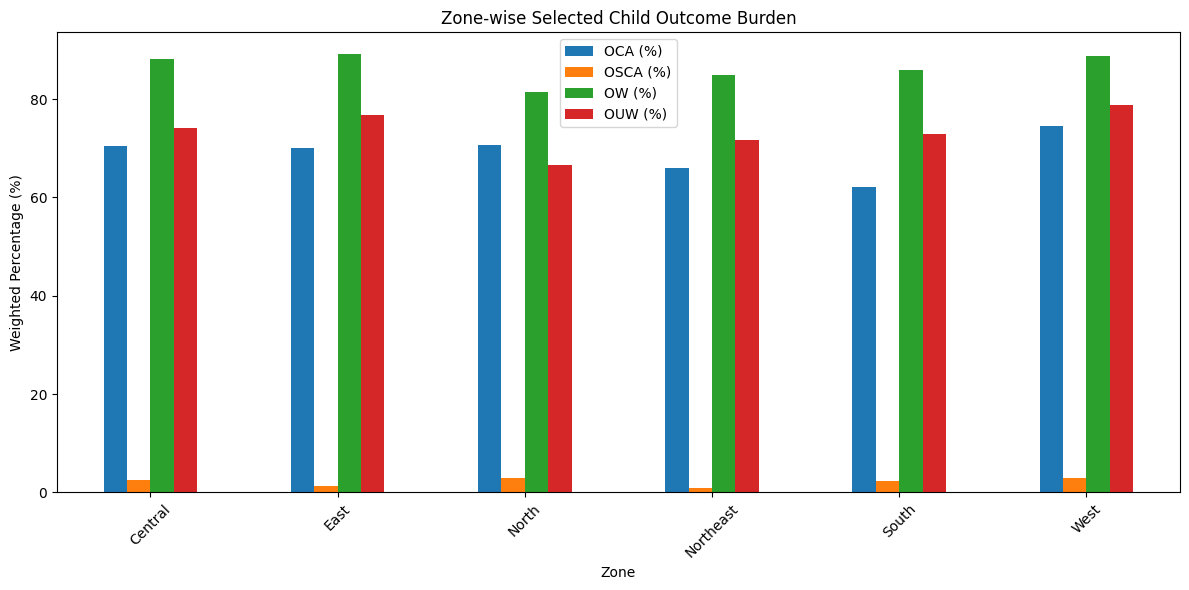

In [18]:
selected_outcomes = ["OCA (%)", "OSCA (%)", "OW (%)", "OUW (%)"]

zone_plot = zone_results.set_index("Zone")[selected_outcomes]

zone_plot.plot(kind="bar", figsize=(12, 6))

plt.title("Zone-wise Selected Child Outcome Burden")
plt.xlabel("Zone")
plt.ylabel("Weighted Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
residence_results = []

for residence, group in df.groupby("Residence"):
    row = {"Residence": residence}

    for outcome in outcome_vars:
        row[outcome + " (%)"] = round(weighted_percentage(group, outcome), 2)

    residence_results.append(row)

residence_results = pd.DataFrame(residence_results)

residence_results

,Residence,OBW (%),OSSB (%),OCA (%),OSCA (%),OS (%),OSS (%),OW (%),OSW (%),OUW (%),OAU (%),OMF (%)
0,1,16.33,10.66,65.56,2.32,78.66,78.46,82.99,82.75,70.79,94.44,82.98
1,2,17.05,10.69,70.66,2.14,83.24,83.10,88.70,88.54,75.37,96.56,88.70


In [20]:
residence_results["Residence"] = residence_results["Residence"].replace({
    1: "Urban",
    2: "Rural"
})

residence_results

,Residence,OBW (%),OSSB (%),OCA (%),OSCA (%),OS (%),OSS (%),OW (%),OSW (%),OUW (%),OAU (%),OMF (%)
0,Urban,16.33,10.66,65.56,2.32,78.66,78.46,82.99,82.75,70.79,94.44,82.98
1,Rural,17.05,10.69,70.66,2.14,83.24,83.10,88.70,88.54,75.37,96.56,88.70


In [21]:
education_results = []

for edu, group in df.groupby("Medu"):
    row = {"Mother Education": edu}

    for outcome in outcome_vars:
        row[outcome + " (%)"] = round(weighted_percentage(group, outcome), 2)

    education_results.append(row)

education_results = pd.DataFrame(education_results)

education_results

,Mother Education,OBW (%),OSSB (%),OCA (%),OSCA (%),OS (%),OSS (%),OW (%),OSW (%),OUW (%),OAU (%),OMF (%)
0,0,18.72,11.43,74.65,2.43,85.97,85.82,92.50,92.41,78.23,98.02,92.51
1,1,19.36,11.79,72.00,2.34,86.55,86.41,91.50,91.39,78.02,98.03,91.52
2,2,16.94,10.84,69.07,2.19,82.55,82.40,87.52,87.35,74.33,96.17,87.52
3,3,13.37,8.88,63.08,1.92,73.67,73.50,78.17,77.84,67.13,92.23,78.17


In [22]:
education_results["Mother Education"] = education_results["Mother Education"].replace({
    0: "No education",
    1: "Primary",
    2: "Secondary",
    3: "Higher"
})

education_results

,Mother Education,OBW (%),OSSB (%),OCA (%),OSCA (%),OS (%),OSS (%),OW (%),OSW (%),OUW (%),OAU (%),OMF (%)
0,No education,18.72,11.43,74.65,2.43,85.97,85.82,92.50,92.41,78.23,98.02,92.51
1,Primary,19.36,11.79,72.00,2.34,86.55,86.41,91.50,91.39,78.02,98.03,91.52
2,Secondary,16.94,10.84,69.07,2.19,82.55,82.40,87.52,87.35,74.33,96.17,87.52
3,Higher,13.37,8.88,63.08,1.92,73.67,73.50,78.17,77.84,67.13,92.23,78.17


In [23]:
wealth_results = []

for wealth, group in df.groupby("Wealthindex"):
    row = {"Wealth Index": wealth}

    for outcome in outcome_vars:
        row[outcome + " (%)"] = round(weighted_percentage(group, outcome), 2)

    wealth_results.append(row)

wealth_results = pd.DataFrame(wealth_results)

wealth_results["Wealth Index"] = wealth_results["Wealth Index"].replace({
    1: "Poorest",
    2: "Poorer",
    3: "Middle",
    4: "Richer",
    5: "Richest"
})

wealth_results

,Wealth Index,OBW (%),OSSB (%),OCA (%),OSCA (%),OS (%),OSS (%),OW (%),OSW (%),OUW (%),OAU (%),OMF (%)
0,Poorest,19.80,12.70,75.14,2.08,86.93,86.82,93.06,92.96,79.75,98.19,93.06
1,Poorer,18.26,11.45,71.44,2.12,84.83,84.61,91.13,91.04,77.82,97.69,91.13
2,Middle,16.28,9.86,69.00,2.45,83.14,83.04,88.32,88.08,74.15,96.27,88.33
3,Richer,15.38,9.76,66.06,2.32,79.70,79.48,84.36,84.12,71.58,94.93,84.36
4,Richest,14.29,9.57,63.91,1.98,74.32,74.20,77.52,77.28,66.25,92.34,77.50
